In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

df = pd.read_csv('data/data.csv')

df

,area,price
0,10,2750
1,100,27500
2,2000,550000
3,3000,565000
4,3200,610000
5,3600,680000
6,4100,725000


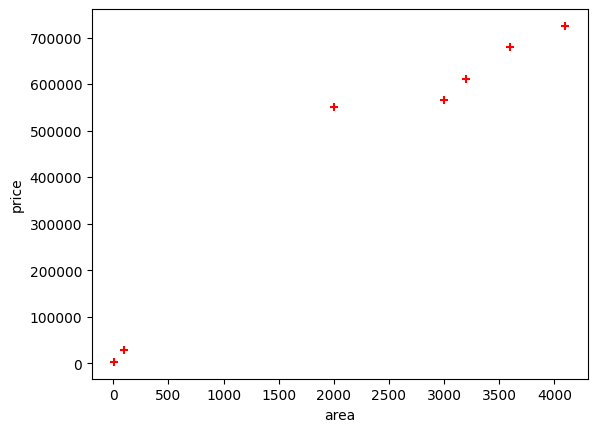

In [2]:
%matplotlib inline
plt.xlabel('area')
plt.ylabel('price')
plt.scatter(df.area,df.price,color='red',marker='+')


In [3]:
reg = linear_model.LinearRegression()
reg.fit(df[['area']],df.price)          # training the model with data

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [4]:
reg.predict([[10]])

c:\Dev\gcp\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([42993.95448204])

Above values are generated using Linear equation -> y = mx + b

y : Dependent variable (in this case it is price)
x : Independent variable (in this case it is area)
m : coefficient
b : intercept


When we train the model, it calculates the coefficient & intercept based on given data.
During prediction, same values are applied to the linear equation and predicted values are generated.

We can fetch coefficient & intercept valuues by executing below :

reg.coef_
reg.intercept_

In [9]:
reg.coef_


array([179.37843906])

In [10]:
reg.intercept_

np.float64(41200.17009142961)

In [11]:
area_arr = np.array([1000,2500,4500,8700,9500,8541,6854,1254,500])

df = pd.DataFrame(area_arr,columns=['area'])
df

df['prices'] = reg.predict(df)

df['prices'] = df['prices'].round(2)

print(df)




   area      prices
0  1000   220578.61
1  2500   489646.27
2  4500   848403.15
3  8700  1601792.59
4  9500  1745295.34
5  8541  1573271.42
6  6854  1270659.99
7  1254   266140.73
8   500   130889.39


Now we'll handle multiple independent variables.
price will be dependent on area, no of bedroom and age of house

equation will be : price = m1 x area + m2 x no. of bedroom + m3 x age + b


In [12]:
df2 = pd.read_csv('data/data2.csv')

df2

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,NaN,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
5,4100,6.0,8,810000


In [13]:
df2.isna().sum()        # to find if there are na values

area        0
bedrooms    1
age         0
price       0
dtype: int64

In [14]:
### Handling NaN values

import math

df2["bedrooms"] = df2["bedrooms"].fillna(math.floor(df2["bedrooms"].median()))

df2

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,4.0,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
5,4100,6.0,8,810000


In [15]:
reg2 = linear_model.LinearRegression()
reg2.fit(df2[['area','bedrooms','age']],df2.price)

print("Coefficient : ",reg2.coef_)
print("Intercept : ",reg2.intercept_)

arr = np.array([3000,4,18])
print(f"Predicted price for {arr[0]} sqr ft, {arr[1]} bedrooms, {arr[2]} years old house : {reg2.predict(arr.reshape(1,3))[0]:.2f}")


Coefficient :  [  112.06244194 23388.88007794 -3231.71790863]
Intercept :  221323.00186540437
Predicted price for 3000 sqr ft, 4 bedrooms, 18 years old house : 592894.93


c:\Dev\gcp\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Exercise :

in the data/hiringdata.csv do the following :
 - handle na values
 - based on experience, test_score, interview score -> calculate the salary to be offered

In [16]:
df_emp = pd.read_csv('data/hiringdata.csv')

df_emp

,experience,test_score,interview_score,salary
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,NaN,7,72000
7,eleven,7.0,8,80000


In [17]:
df_emp.fillna(
    {"experience":0,
    "test_score":df_emp['test_score'].median(),
    "interview_score":df_emp['interview_score'].median()
    },inplace=True)

df_emp




,experience,test_score,interview_score,salary
0,0,8.0,9,50000
1,0,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,8.0,7,72000
7,eleven,7.0,8,80000


In [18]:
word_to_num = {
    "zero":0, "one":1, "two":2, "three":3, "four":4, "five":5,
    "six":6, "seven":7, "eight":8, "nine":9, "ten":10,
    "eleven":11, "twelve":12, "thirteen":13, "fourteen":14, "fifteen":15
}

df_emp['experience'] = df_emp['experience'].apply(lambda x: word_to_num[x] if x in word_to_num else x)

df_emp

,experience,test_score,interview_score,salary
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,8.0,7,72000
7,11,7.0,8,80000


In [19]:
emp_reg = linear_model.LinearRegression()

emp_reg.fit(df_emp[["experience", "test_score", "interview_score"]],df_emp["salary"])



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
print(emp_reg.coef_)

[2812.95487627 1845.70596798 2205.24017467]


In [23]:
emp_reg.predict([[4.5,5,6]])

c:\Dev\gcp\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([52855.53129549])